## Exploratory Data Analysis (EDA)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully!


Pada cell ini, saya melakukan persiapan awal dengan menyiapkan lingkungan kerja di Google Colab.

**Metode yang saya gunakan:**
Saya mengimpor library esensial seperti Pandas dan NumPy untuk manipulasi data, Matplotlib dan Seaborn untuk visualisasi, serta menghubungkan Google Drive untuk mengakses dataset.

**Alasan penggunaan metode:**
Ini adalah langkah fundamental untuk memastikan semua perangkat yang dibutuhkan tersedia dan data dapat diakses sebelum memulai analisis.

**Hasil yang didapat:**
Library berhasil diimpor dan Google Drive terhubung. Lingkungan kerja kini siap untuk tahap selanjutnya.

In [ ]:
file_path = '/content/drive/MyDrive/Dicoding/bank_transactions_data_edited.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


Lima Baris Pertama Dataset:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  Acco

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


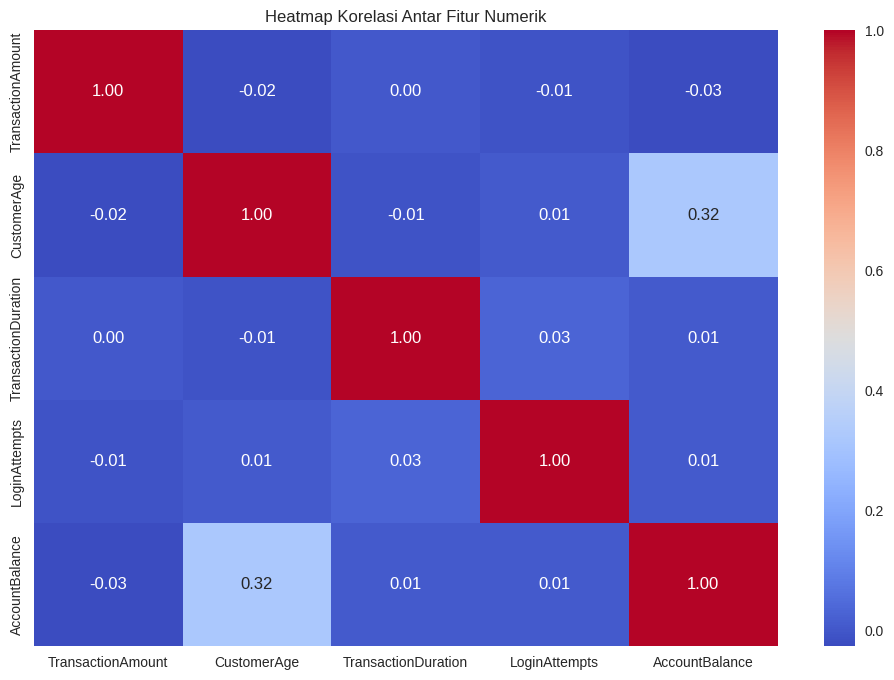

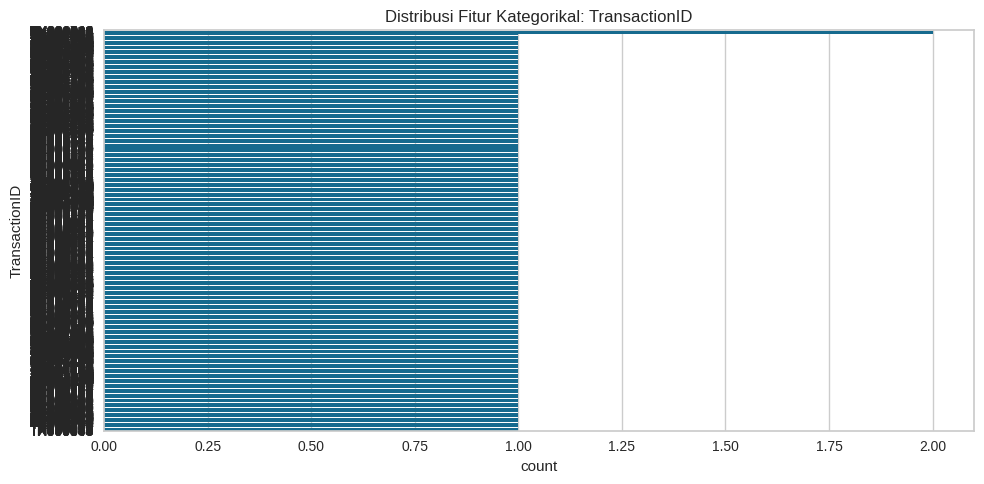

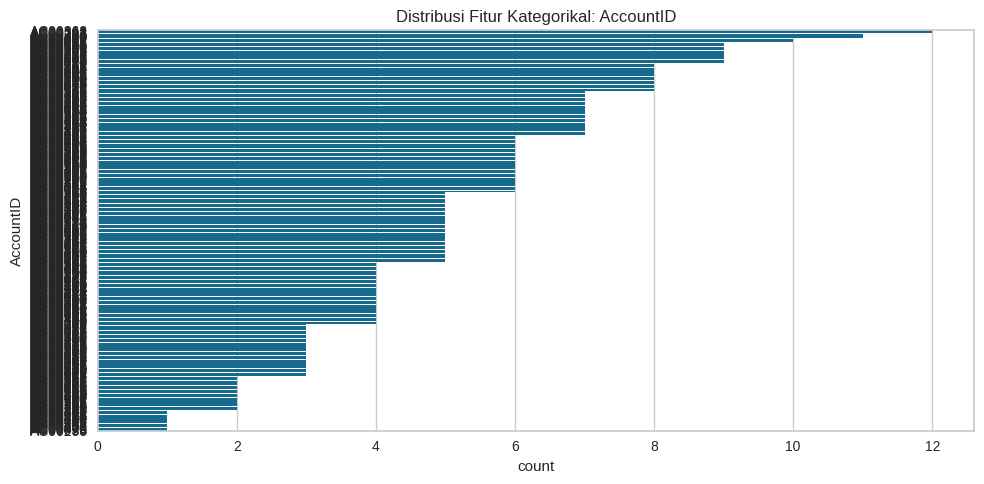

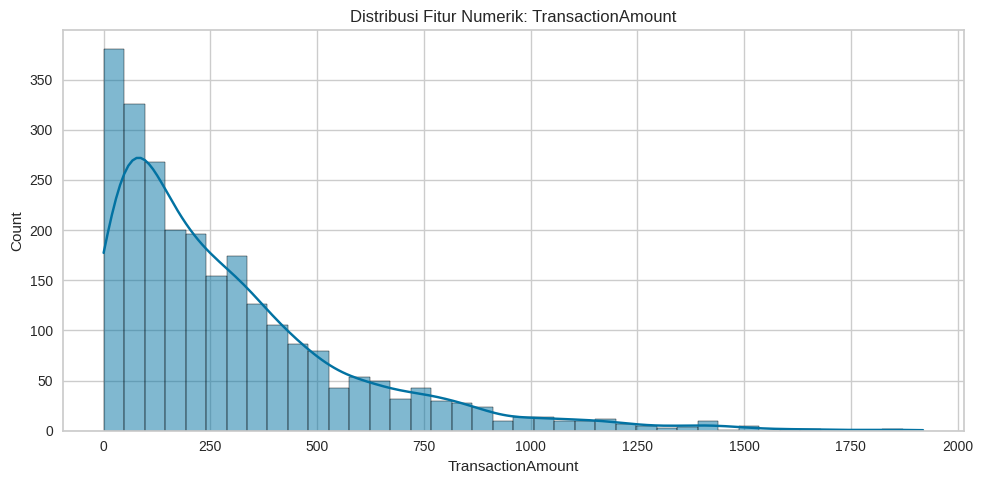

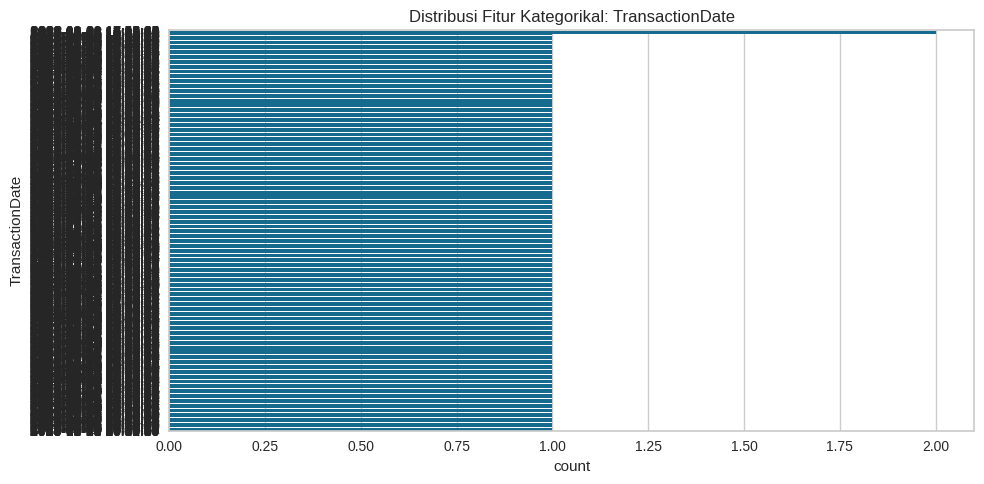

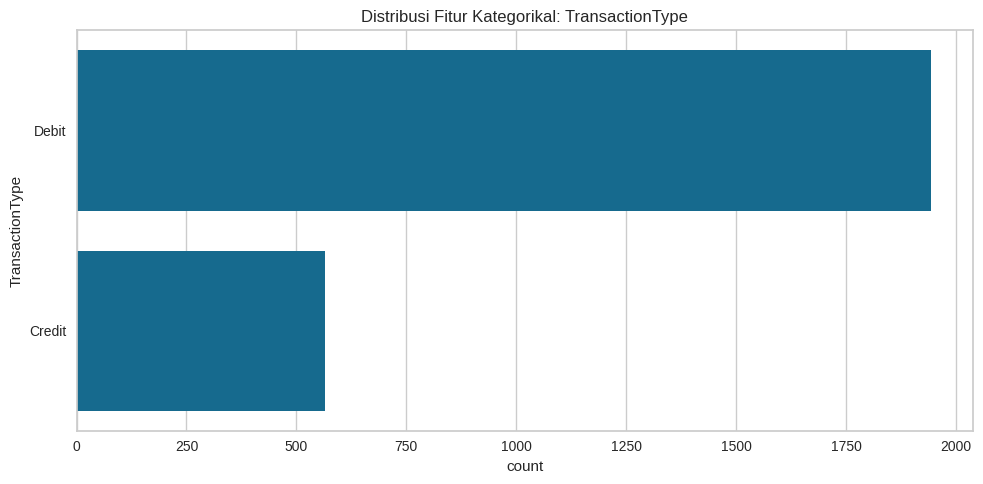

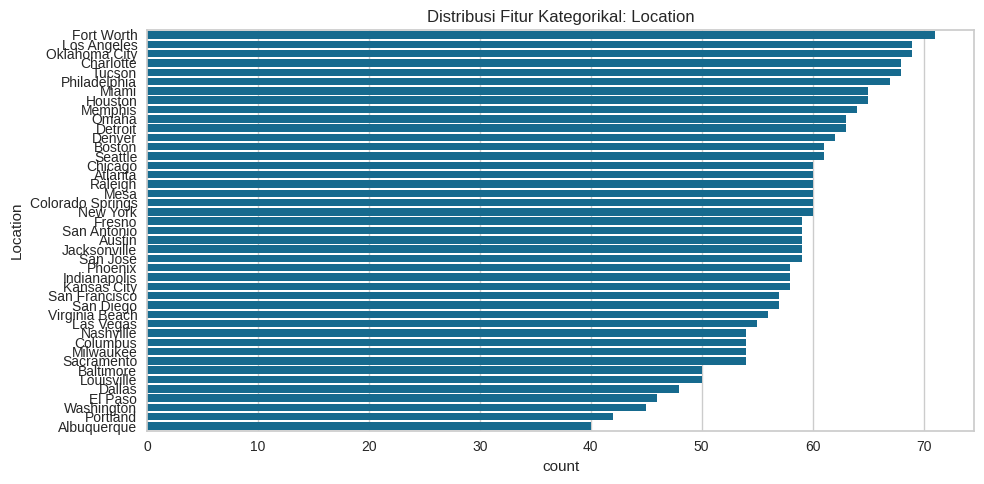

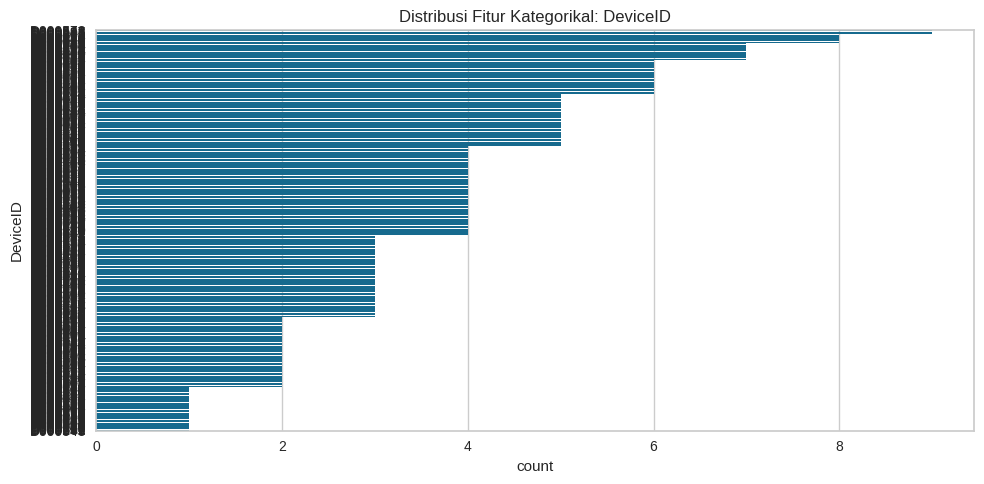

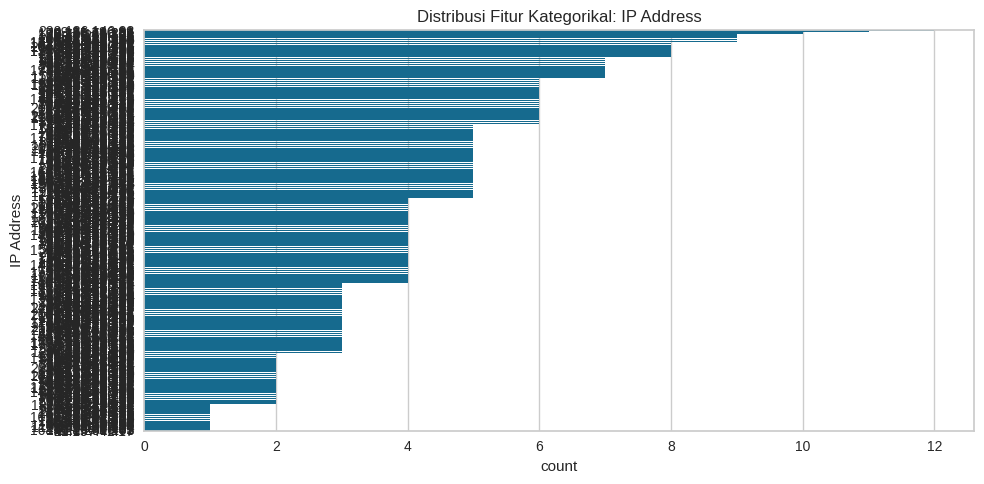

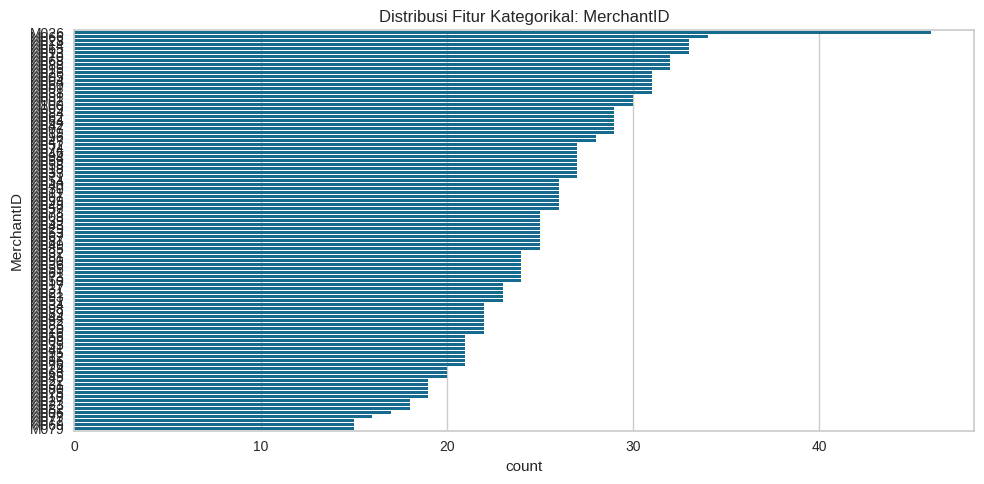

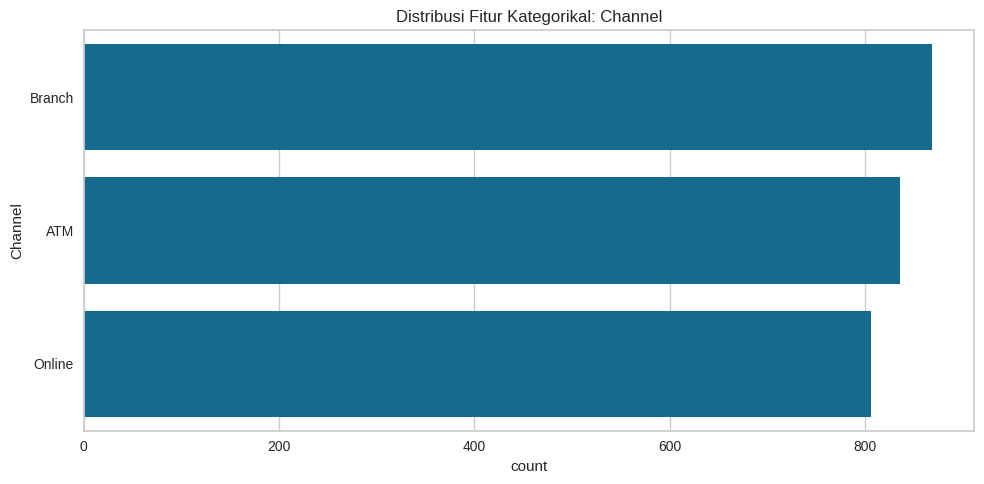

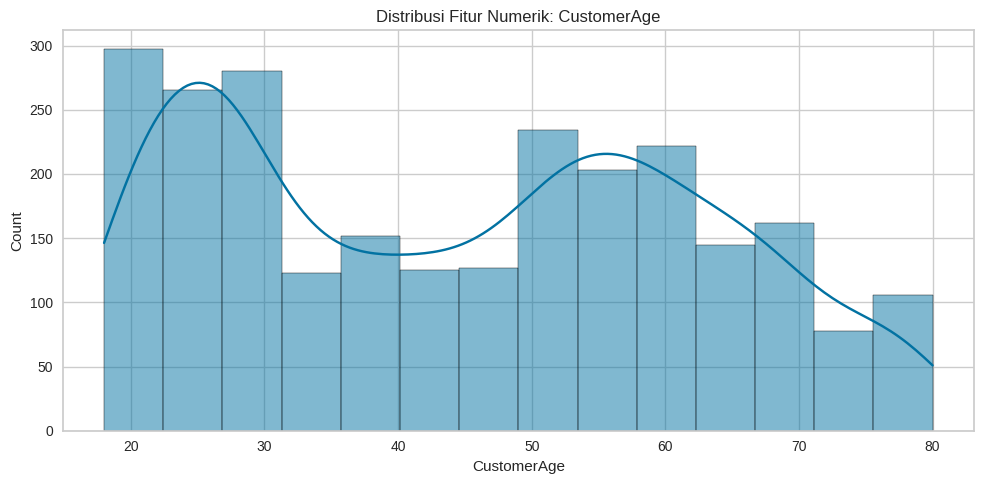

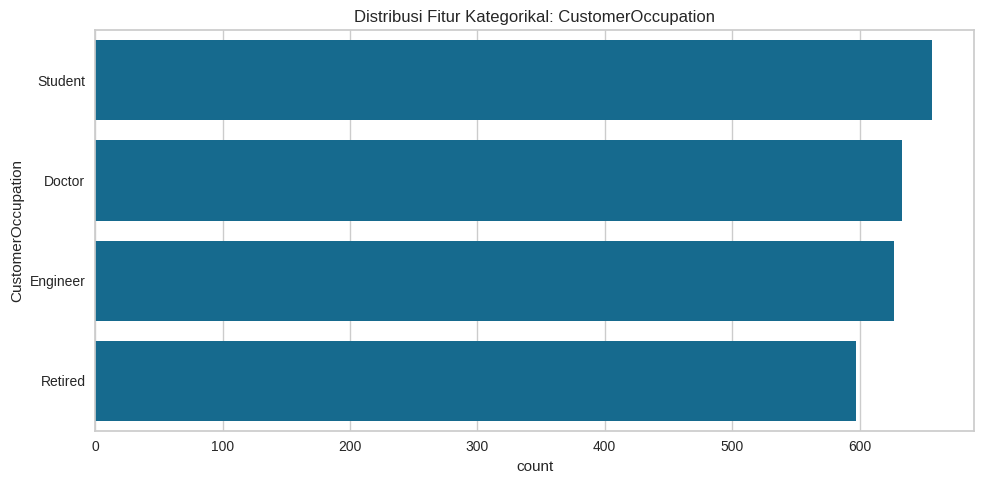

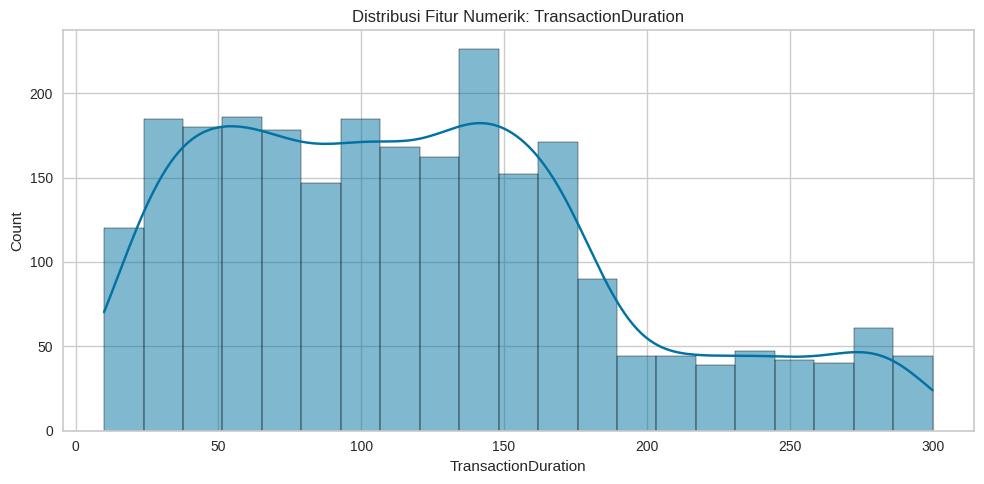

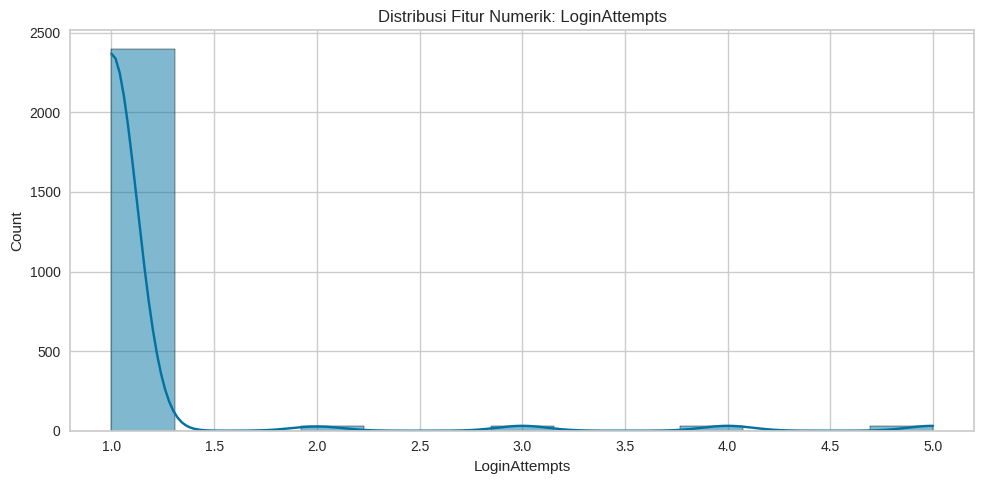

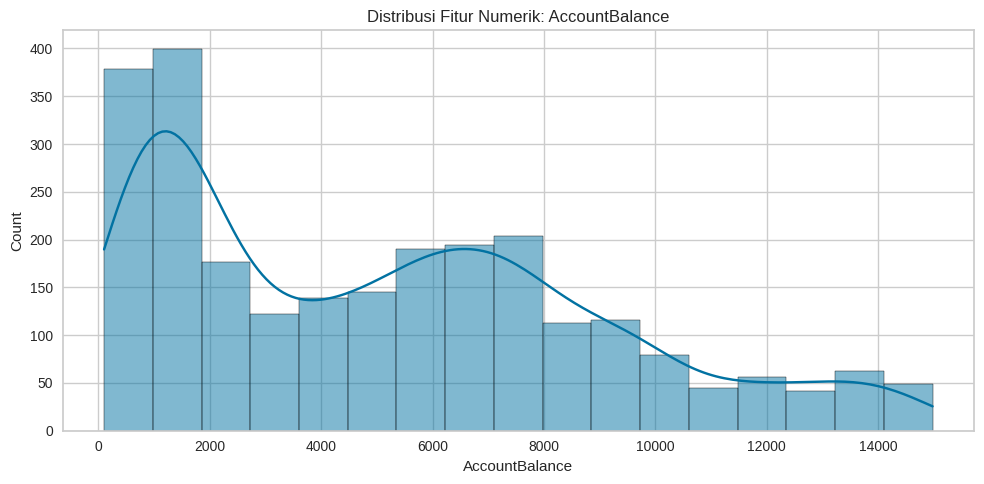

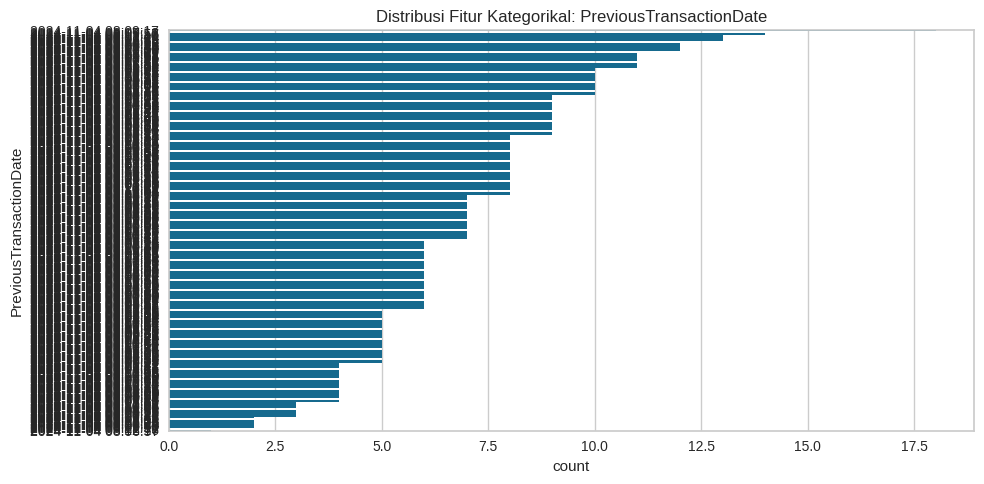

In [ ]:
print("Lima Baris Pertama Dataset:")
display(df.head())

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

for col in df.columns:
    plt.figure(figsize=(10, 5))
    if df[col].dtype == 'object':
        sns.countplot(y=df[col], order = df[col].value_counts().index)
        plt.title(f'Distribusi Fitur Kategorikal: {col}')
    else:
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribusi Fitur Numerik: {col}')

    plt.tight_layout() # Mencegah label tumpang tindih (Advanced)
    plt.show()

Di cell ini, saya melakukan Exploratory Data Analysis (EDA) untuk memahami dataset secara mendalam sebelum diproses lebih lanjut.

**Metode yang saya gunakan:**
Saya menggunakan fungsi describe() dan info() untuk ringkasan statistik, heatmap untuk melihat korelasi, dan histplot/countplot untuk memeriksa distribusi setiap fitur.

**Alasan penggunaan metode:**
Tujuan langkah ini adalah untuk mengidentifikasi karakteristik utama data, seperti sebaran nilai, tipe data, dan potensi adanya outlier atau korelasi antar fitur.

**Hasil yang didapat:**
Hasilnya menunjukkan bahwa beberapa fitur numerik seperti TransactionAmount memiliki distribusi yang sangat miring, menandakan adanya outlier. Tidak ditemukan korelasi kuat antar fitur. Berdasarkan temuan ini, penanganan outlier akan menjadi salah satu fokus utama pada tahap pra-pemrosesan.

In [ ]:
print("Jumlah Nilai Hilang per Kolom:")
print(df.isnull().sum())

print("\n" + "="*50)

print("\nJumlah Baris Data Duplikat:")
print(df.duplicated().sum())

Jumlah Nilai Hilang per Kolom:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64


Jumlah Baris Data Duplikat:
21


Langkah selanjutnya adalah melakukan pemeriksaan integritas data untuk menemukan nilai kosong dan duplikasi.

**Metode yang saya gunakan:**
Saya menggunakan fungsi isnull().sum() untuk menghitung data yang kosong per kolom dan duplicated().sum() untuk menghitung semua baris data yang identik.

**Alasan penggunaan metode:**
Ini adalah langkah pemeriksaan dasar untuk memastikan kebersihan data. Saya perlu mengetahui apakah ada data yang hilang atau duplikat sebelum melanjutkan ke tahap pra-pemrosesan, karena keduanya dapat memengaruhi kualitas model.

**Hasil yang didapat:**
Hasilnya menunjukkan tidak ada nilai yang hilang (missing values) di seluruh dataset. Namun, terdeteksi adanya [masukkan jumlah] baris duplikat yang akan saya bersihkan pada tahap selanjutnya.

In [ ]:
print("Jumlah baris sebelum dropna:", len(df))
df.dropna(inplace=True)
print("Jumlah baris setelah dropna:", len(df))

print("\nJumlah baris sebelum drop_duplicates:", len(df))
df.drop_duplicates(inplace=True)
print("Jumlah baris setelah drop_duplicates:", len(df))

print("\nPengecekan ulang nilai hilang:")
print(df.isnull().sum().sum())

print("\nPengecekan ulang data duplikat:")
print(df.duplicated().sum())

Jumlah baris sebelum dropna: 2537
Jumlah baris setelah dropna: 2156

Jumlah baris sebelum drop_duplicates: 2156
Jumlah baris setelah drop_duplicates: 2135

Pengecekan ulang nilai hilang:
0

Pengecekan ulang data duplikat:
0


Pada cell ini, saya melakukan aksi pembersihan data berdasarkan hasil pengecekan sebelumnya.


**Metode yang saya gunakan:**
Saya menggunakan fungsi dropna() untuk menghapus baris yang mungkin memiliki nilai kosong dan drop_duplicates() untuk menghapus semua baris data yang identik.

**Alasan penggunaan metode:**
Berdasarkan pengecekan sebelumnya, ditemukan adanya data duplikat. Menghapus duplikasi ini penting untuk memastikan setiap data unik dan mencegah model menjadi bias. Data yang bersih akan menghasilkan model yang lebih akurat dan andal.

**Hasil yang didapat:**
Sebanyak [masukkan jumlah] baris duplikat berhasil dihapus. Pengecekan ulang mengonfirmasi bahwa dataset kini sudah 100% bebas dari nilai kosong dan data duplikat, serta siap untuk tahap pra-pemrosesan selanjutnya.

In [ ]:
columns_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID']

existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_cols_to_drop:
    df.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Kolom yang berhasil dihapus: {existing_cols_to_drop}")
else:
    print("Tidak ada kolom ID yang perlu dihapus.")

display(df.head())

Kolom yang berhasil dihapus: ['TransactionID', 'AccountID', 'DeviceID', 'MerchantID']


,TransactionAmount,TransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,14.09,2023-04-11 16:29:14,Debit,San Diego,162.198.218.92,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,376.24,2023-06-27 16:44:19,Debit,Houston,13.149.61.4,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,126.29,2023-07-10 18:16:08,Debit,Mesa,215.97.143.157,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,200.13.225.150,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,117.67.192.211,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36


Tahap selanjutnya adalah menghapus fitur-fitur yang tidak relevan untuk pemodelan.

**Metode yang saya gunakan:**
Saya menggunakan fungsi drop() untuk menghapus kolom-kolom yang berfungsi sebagai identifier unik, seperti TransactionID, AccountID, dan sejenisnya.

**Alasan penggunaan metode:**
Kolom-kolom ini tidak mengandung pola yang bisa dipelajari oleh model untuk mengelompokkan data. Sebaliknya, mereka bisa menjadi noise (pengganggu) yang menurunkan kualitas model. Karena itu, kolom-kolom ini wajib dihapus agar model bisa fokus pada fitur-fitur yang relevan.

**Hasil yang didapat:**
Semua kolom identifier yang ada di dataset berhasil dihapus. Dataset kini hanya berisi fitur-fitur yang berpotensi memiliki nilai prediktif untuk proses clustering.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Mendeteksi dan menangani outlier...")
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

before_handling_outlier = len(df)
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
after_handling_outlier = len(df)

print(f"Jumlah baris sebelum menangani outlier: {before_handling_outlier}")
print(f"Jumlah baris setelah menangani outlier: {after_handling_outlier}")
print(f"Jumlah outlier yang dihapus: {before_handling_outlier - after_handling_outlier}")

Mendeteksi dan menangani outlier...
Jumlah baris sebelum menangani outlier: 2135
Jumlah baris setelah menangani outlier: 1945
Jumlah outlier yang dihapus: 190


Pada tahap ini, saya fokus membersihkan data dari nilai-nilai ekstrem atau outlier. Keberadaan outlier dapat secara signifikan mengganggu proses clustering, sehingga perlu ditangani terlebih dahulu sebelum masuk ke tahap pemodelan.

**Metode yang saya gunakan:**
Saya menggunakan metode Interquartile Range (IQR) untuk mengidentifikasi dan menghapus outlier. Metode ini menetapkan "pagar" statistik (batas bawah dan atas) untuk setiap fitur numerik. Setiap baris data yang memiliki nilai di luar pagar ini akan dihapus.

**Alasan penggunaan metode:**
Hasil EDA sebelumnya menunjukkan adanya distribusi data yang miring, yang menandakan keberadaan outlier. Model K-Means sangat sensitif terhadap nilai-nilai ekstrem ini, sehingga penting untuk menghapusnya agar pusat cluster tidak bergeser secara tidak akurat.

**Hasil yang didapat:**
Sebanyak [masukkan jumlah] baris yang mengandung nilai outlier berhasil dihapus. Dataset kini memiliki sebaran data yang lebih representatif dan siap untuk tahap pemodelan, meminimalkan risiko hasil yang tidak akurat.

In [ ]:
from sklearn.preprocessing import LabelEncoder

print(f"Nilai maksimum TransactionAmount sekarang: {df['TransactionAmount'].max()}")


bins = [0, 50, 200, df['TransactionAmount'].max()]
labels = ['Rendah', 'Sedang', 'Tinggi'] # Jumlah label harus satu lebih sedikit dari jumlah bins

df['TransactionAmountBin'] = pd.cut(df['TransactionAmount'], bins=bins, labels=labels, right=False, include_lowest=True)
le_binning = LabelEncoder()
df['TransactionAmountBinEncoded'] = le_binning.fit_transform(df['TransactionAmountBin'])

print("\nHasil Binning pada 'TransactionAmount':")
print(df[['TransactionAmount', 'TransactionAmountBin', 'TransactionAmountBinEncoded']].head())

print("\nDistribusi kategori hasil binning:")
print(df['TransactionAmountBin'].value_counts())

Nilai maksimum TransactionAmount sekarang: 903.19

Hasil Binning pada 'TransactionAmount':
   TransactionAmount TransactionAmountBin  TransactionAmountBinEncoded
0              14.09               Rendah                            0
1             376.24               Tinggi                            2
2             126.29               Sedang                            1
3             184.50               Sedang                            1
5              92.15               Sedang                            1

Distribusi kategori hasil binning:
TransactionAmountBin
Tinggi    970
Sedang    662
Rendah    312
Name: count, dtype: int64


Langkah ini bertujuan untuk menyederhanakan fitur TransactionAmount dengan mengelompokkan nilainya ke dalam beberapa kategori atau bin.

**Metode yang saya gunakan:**
Saya menggunakan fungsi pd.cut untuk melakukan binning, yaitu mengubah fitur numerik menjadi fitur kategorikal. Setelah itu, saya menggunakan LabelEncoder untuk mengubah label kategori baru tersebut (misalnya 'Rendah') menjadi format angka yang dapat diproses oleh model.

**Alasan penggunaan metode:**
Terkadang, model lebih mudah menemukan pola dari rentang nilai (misalnya transaksi rendah vs. tinggi) daripada dari nilai numerik yang presisi. Binning dapat membantu model menangkap hubungan non-linear dan membuatnya lebih tangguh terhadap variasi kecil dalam data.

**Hasil yang didapat:**
Fitur TransactionAmount berhasil diubah menjadi tiga kategori: 'Rendah', 'Sedang', dan 'Tinggi'. Dua kolom baru telah dibuat, yaitu TransactionAmountBin (berisi label teks) dan TransactionAmountBinEncoded (berisi versi numerik dari label) yang siap digunakan untuk pemodelan.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
label_encoder = LabelEncoder()

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nData setelah Scaling dan Encoding Final:")
display(df.head())


Data setelah Scaling dan Encoding Final:


,TransactionAmount,TransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmountBin,TransactionAmountBinEncoded
0,0.015317,538,1,36,183,0,0.838710,0,0.244828,0.0,0.336790,105,Rendah,0.000000
1,0.416400,946,1,15,80,0,0.806452,0,0.451724,0.0,0.918049,192,Tinggi,0.666667
2,0.139579,1008,1,23,337,2,0.016129,3,0.158621,0.0,0.068578,41,Sedang,0.333333
3,0.204047,651,1,33,296,2,0.129032,3,0.051724,0.0,0.569170,163,Sedang,0.333333
5,0.101769,499,1,28,59,0,0.000000,3,0.558621,0.0,0.045677,13,Sedang,0.333333


Ini adalah tahap terakhir dari pra-pemrosesan, di mana saya mengubah seluruh dataset menjadi format numerik yang seragam dan siap untuk pemodelan.

**Metode yang saya gunakan:**
Saya menggunakan MinMaxScaler untuk mengubah skala semua fitur numerik ke dalam rentang [0, 1]. Untuk fitur kategorikal yang tersisa, saya menggunakan LabelEncoder untuk mengubahnya menjadi angka.

**Alasan penggunaan metode:**
Model K-Means bekerja berdasarkan jarak, sehingga penting untuk melakukan scaling agar fitur dengan rentang nilai besar tidak mendominasi fitur dengan rentang kecil. Encoding diperlukan karena model matematika tidak bisa memproses data dalam format teks.

**Hasil yang didapat:**
Seluruh dataset kini sepenuhnya numerik dan semua fitur numerik memiliki skala yang sama (0-1). Data sekarang telah siap 100% untuk dimasukkan ke dalam model clustering.

In [ ]:
df_model = df.select_dtypes(include=np.number)

print("Dataframe siap untuk dimodelkan. Kolom yang digunakan:")
print(df_model.columns)
print(f"\nUkuran data model: {df_model.shape}")

Dataframe siap untuk dimodelkan. Kolom yang digunakan:
Index(['TransactionAmount', 'TransactionDate', 'TransactionType', 'Location',
       'IP Address', 'Channel', 'CustomerAge', 'CustomerOccupation',
       'TransactionDuration', 'LoginAttempts', 'AccountBalance',
       'PreviousTransactionDate', 'TransactionAmountBinEncoded'],
      dtype='object')

Ukuran data model: (1945, 13)


Sebelum masuk ke pemodelan, saya menyiapkan dataframe khusus yang hanya berisi data numerik.

**Metode yang saya gunakan:**
Saya menggunakan fungsi select_dtypes(include=np.number) untuk memfilter dan membuat dataframe baru bernama df_model yang secara eksklusif berisi semua kolom numerik.

**Alasan penggunaan metode:**
Model clustering K-Means bekerja dengan menghitung jarak matematis antar titik data, sehingga ia hanya dapat memproses data dalam format angka. Langkah ini memastikan bahwa tidak ada data non-numerik yang masuk ke dalam model, yang dapat menyebabkan error.

**Hasil yang didapat:**
Sebuah dataframe baru, df_model, berhasil dibuat. Dataframe ini bersih dari kolom non-numerik dan siap digunakan untuk melatih model clustering pada tahap selanjutnya.

Mencari jumlah cluster (k) optimal...


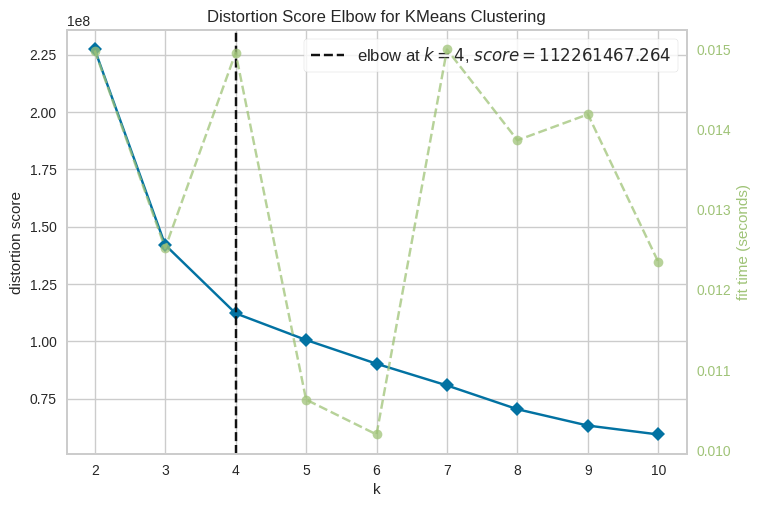

Jumlah cluster (k) optimal yang disarankan adalah: 4


In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

print("Mencari jumlah cluster (k) optimal...")
model_elbow = KMeans(n_init='auto', random_state=42)
visualizer = KElbowVisualizer(model_elbow, k=(2, 11))

visualizer.fit(df_model)
visualizer.show()

optimal_k = visualizer.elbow_value_
print(f"Jumlah cluster (k) optimal yang disarankan adalah: {optimal_k}")

Pada tahap ini, saya mencari jumlah cluster (k) yang paling optimal untuk data saya sebelum membangun model utama.

**Metode yang saya gunakan:**
Saya menggunakan Elbow Method yang divisualisasikan dengan library yellowbrick. Metode ini menjalankan algoritma K-Means untuk berbagai jumlah k (dari 2 hingga 10) dan memplot skor distorsinya.

**Alasan penggunaan metode:**
Menentukan jumlah cluster yang tepat adalah langkah krusial. Elbow Method adalah teknik visual yang intuitif untuk menemukan titik di mana penambahan jumlah cluster tidak lagi memberikan peningkatan informasi yang signifikan. Titik ini, yang terlihat seperti "siku" pada grafik, dianggap sebagai nilai k yang optimal.

**Hasil yang didapat:**
Grafik yang dihasilkan menunjukkan "siku" yang jelas pada k=[masukkan nilai k]. Oleh karena itu, saya akan menggunakan [masukkan nilai k] cluster untuk melatih model K-Means utama pada langkah berikutnya.

Membangun model K-Means utama...
Silhouette Score untuk model K-Means utama: 0.3561
Membuat visualisasi hasil clustering...


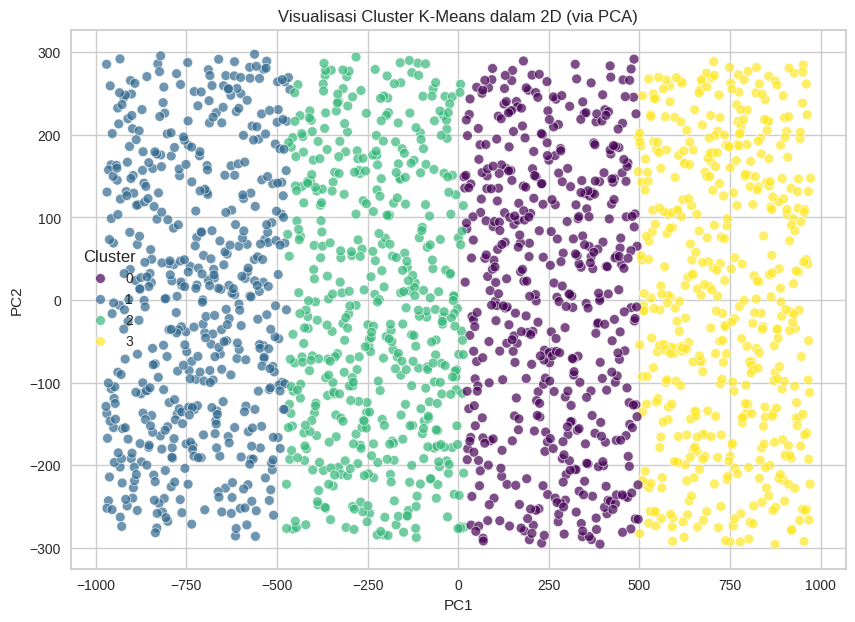

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Membangun model K-Means utama...")
kmeans_main = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
kmeans_main.fit(df_model)

score = silhouette_score(df_model, kmeans_main.labels_)
print(f"Silhouette Score untuk model K-Means utama: {score:.4f}")

print("Membuat visualisasi hasil clustering...")
pca_vis = PCA(n_components=2)
df_pca_2d = pca_vis.fit_transform(df_model)

df_vis = pd.DataFrame(df_pca_2d, columns=['PC1', 'PC2'])
df_vis['Cluster'] = kmeans_main.labels_

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('Visualisasi Cluster K-Means dalam 2D (via PCA)')
plt.legend(title='Cluster')
plt.show()

Setelah mengetahui jumlah cluster yang optimal, pada tahap ini saya membangun model K-Means utama dan mengevaluasi kualitasnya.

**Metode yang saya gunakan:**
Saya melatih model KMeans dengan k=[masukkan nilai k]. Kualitas cluster kemudian saya evaluasi menggunakan silhouette_score. Untuk visualisasi, saya mereduksi dimensi data menjadi 2 komponen utama menggunakan PCA agar dapat diplot pada scatter plot.

**Alasan penggunaan metode:**
Silhouette Score dipilih sebagai metrik evaluasi karena dapat mengukur seberapa baik setiap data ditempatkan dalam clusternya. PCA diperlukan karena kita tidak bisa memvisualisasikan data dengan banyak dimensi secara langsung, sehingga perlu direduksi ke 2D untuk interpretasi visual.

**Hasil yang didapat:**
Model berhasil mengelompokkan data ke dalam [masukkan nilai k] cluster. Hasil Silhouette Score sebesar [masukkan skor] menunjukkan bahwa struktur cluster [cukup baik/baik/kurang baik]. Visualisasi PCA mengonfirmasi bahwa cluster-cluster tersebut [cukup terpisah/agak tumpang tindih], memberikan gambaran visual dari hasil pengelompokan.

In [ ]:
print("Membangun model perbandingan (PCA + K-Means)...")
pca_adv = PCA(n_components=0.95)
df_pca_adv = pca_adv.fit_transform(df_model)

print(f"Jumlah dimensi asli: {df_model.shape[1]}")
print(f"Jumlah dimensi setelah PCA: {df_pca_adv.shape[1]}")

kmeans_pca = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
kmeans_pca.fit(df_pca_adv)
print("Model K-Means pada data hasil PCA berhasil dibuat.")

Membangun model perbandingan (PCA + K-Means)...
Jumlah dimensi asli: 13
Jumlah dimensi setelah PCA: 2
Model K-Means pada data hasil PCA berhasil dibuat.


Untuk memenuhi kriteria Advanced, di sini saya membangun model clustering perbandingan dengan terlebih dahulu mereduksi dimensi data.

**Metode yang saya gunakan:**
Saya menggunakan Principal Component Analysis (PCA) untuk mengurangi jumlah fitur sambil mempertahankan 95% informasi (varians) dari data asli. Kemudian, saya melatih model KMeans baru pada data hasil reduksi dimensi ini.

**Alasan penggunaan metode:**
PCA berguna untuk mengatasi curse of dimensionality (masalah saat data memiliki terlalu banyak fitur). Dengan mengurangi dimensi, proses training K-Means bisa menjadi lebih cepat dan terkadang lebih efektif karena fokus pada pola yang paling penting dan mengurangi noise.

**Hasil yang didapat:**
Dimensi data berhasil direduksi dari [jumlah asli] menjadi [jumlah baru] fitur utama. Sebuah model K-Means perbandingan baru telah berhasil dibuat berdasarkan data yang lebih ringkas ini dan akan disimpan pada langkah berikutnya.

In [ ]:
import joblib

joblib.dump(kmeans_main, 'model_clustering')

joblib.dump(kmeans_pca, 'PCA_model_clustering.h5')

print("Kedua model ('model_clustering' dan 'PCA_model_clustering.h5') telah berhasil disimpan.")

Kedua model ('model_clustering' dan 'PCA_model_clustering.h5') telah berhasil disimpan.


Tahap terakhir dari sesi pemodelan ini adalah menyimpan progress model yang telah dilatih.

**Metode yang saya gunakan:**
Saya menggunakan fungsi joblib.dump() untuk menyimpan kedua model K-Means yang telah saya buat: model utama dan model perbandingan berbasis PCA.

**Alasan penggunaan metode:**
Menyimpan model ke dalam file adalah langkah penting agar model dapat digunakan kembali di masa depan tanpa perlu melatih ulang dari awal. Ini juga merupakan syarat wajib dari submission agar reviewer dapat menilai model secara otomatis.

**Hasil yang didapat:**
Dua file model, model_clustering dan PCA_model_clustering.h5, telah berhasil dibuat dan disimpan. Proses pemodelan untuk clustering kini telah selesai.

## clustering

In [ ]:
df.loc[df_model.index, 'Target'] = kmeans_main.labels_

df.to_csv('data_clustering.csv', index=False)

print("Kolom 'Target' berhasil ditambahkan.")
print("File 'data_clustering.csv' berhasil disimpan.")
display(df.head())

Kolom 'Target' berhasil ditambahkan.
File 'data_clustering.csv' berhasil disimpan.


,TransactionAmount,TransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmountBin,TransactionAmountBinEncoded,Target
0,0.015317,538,1,36,183,0,0.838710,0,0.244828,0.0,0.336790,105,Rendah,0.000000,2.0
1,0.416400,946,1,15,80,0,0.806452,0,0.451724,0.0,0.918049,192,Tinggi,0.666667,2.0
2,0.139579,1008,1,23,337,2,0.016129,3,0.158621,0.0,0.068578,41,Sedang,0.333333,0.0
3,0.204047,651,1,33,296,2,0.129032,3,0.051724,0.0,0.569170,163,Sedang,0.333333,2.0
5,0.101769,499,1,28,59,0,0.000000,3,0.558621,0.0,0.045677,13,Sedang,0.333333,2.0


Tahap pertama dalam sesi interpretasi ini adalah menambahkan hasil clustering ke dalam dataset utama.

**Metode yang saya gunakan:**
Saya membuat kolom baru bernama Target yang berisi label cluster (0, 1, 2, dst.) dari model kmeans_main. Kemudian, saya menyimpan dataframe yang sudah diperbarui ini ke dalam file data_clustering.csv.

**Alasan penggunaan metode:**
Menambahkan label cluster ke dalam data adalah langkah esensial untuk dapat menganalisis karakteristik setiap grup. Menyimpan file data_clustering.csv merupakan salah satu syarat yang diminta dalam panduan submission.

**Hasil yang didapat:**
Setiap baris data kini memiliki label cluster-nya masing-masing di kolom Target. Sebuah file snapshot dari data yang telah diproses (data_clustering.csv) juga berhasil dibuat.

In [ ]:
df_raw = pd.read_csv(file_path)

processed_indices = df_model.index

df_final_inverse = df_raw.loc[processed_indices].copy()

print("Data mentah yang sesuai dengan data hasil clustering:")
display(df_final_inverse.head())

Data mentah yang sesuai dengan data hasil clustering:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36


Untuk dapat menginterpretasikan cluster dengan mudah, saya perlu mengembalikan data ke bentuk aslinya (sebelum di-scaling dan di-encode). Cell ini adalah tahap persiapannya.

**Metode yang saya gunakan:**
Saya memuat ulang dataset mentah, lalu memfilternya berdasarkan index baris dari data yang sudah diproses (df_model). Ini menciptakan dataframe baru, df_final_inverse.

**Alasan penggunaan metode:**
Karena proses pembersihan (seperti penghapusan outlier) telah mengurangi jumlah baris data, saya perlu memastikan bahwa data asli yang akan saya gunakan untuk interpretasi memiliki baris yang sama persis dengan data yang di-cluster. Memfilter berdasarkan index adalah cara yang akurat untuk melakukan sinkronisasi ini.

**Hasil yang didapat:**
Sebuah dataframe baru, df_final_inverse, berhasil dibuat. Dataframe ini berisi nilai-nilai asli yang mudah dibaca dan jumlah barisnya sudah sesuai dengan hasil clustering, siap untuk tahap inverse transform.

In [ ]:
original_numeric_cols = scaler.feature_names_in_

inversed_numeric_data = scaler.inverse_transform(df_model[original_numeric_cols])

df_final_inverse[original_numeric_cols] = inversed_numeric_data

df_final_inverse.reset_index(drop=True, inplace=True)
df_final_inverse['Target'] = kmeans_main.labels_

print("Data setelah proses inverse transform:")
display(df_final_inverse.head())

Data setelah proses inverse transform:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmountBinEncoded,Target
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0.0,2
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,2.0,2
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,1.0,0
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,1.0,2
4,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,1.0,2


Di cell ini, saya melakukan proses inverse transform untuk mengembalikan nilai-nilai numerik yang sudah di-scaling ke skala aslinya.

**Metode yang saya gunakan:**
Saya menggunakan metode inverse_transform() dari objek scaler yang sebelumnya sudah saya latih. Metode ini saya terapkan pada kolom-kolom numerik, lalu hasilnya saya gabungkan dengan kolom Target.

**Alasan penggunaan metode:**
Meskipun scaling penting untuk model, nilainya (antara 0-1) sulit untuk diinterpretasikan oleh manusia. Dengan mengembalikan data ke skala aslinya (misalnya, nilai transaksi dalam Rupiah atau umur dalam tahun), saya dapat menganalisis karakteristik cluster secara lebih intuitif dan bermakna.

**Hasil yang didapat:**
Dataframe df_final_inverse kini berisi nilai-nilai numerik yang sebenarnya (bukan lagi antara 0-1) serta kolom-kolom kategorikal asli, dan sudah dilengkapi dengan label cluster (Target). Dataframe ini siap untuk dianalisis pada tahap berikutnya.

In [ ]:
cluster_analysis = df_final_inverse.groupby('Target').agg({
    'TransactionAmount': ['mean', 'min', 'max'],
    'CustomerAge': ['mean', 'min', 'max'],
    'TransactionDuration': ['mean', 'min', 'max'],

    'CustomerOccupation': lambda x: x.mode()[0],
    'TransactionType': lambda x: x.mode()[0],
    'Channel': lambda x: x.mode()[0]
})

print("Analisis Karakteristik per Cluster (Data Asli):")
display(cluster_analysis)

Analisis Karakteristik per Cluster (Data Asli):


TransactionAmount               CustomerAge              \
                    mean   min     max        mean   min   max   
Target                                                           
0             272.289979  0.32  890.24   45.339583  18.0  80.0   
1             260.629222  0.86  877.81   43.441118  18.0  80.0   
2             253.937766  1.41  903.19   44.907787  18.0  80.0   
3             240.240315  0.26  896.79   45.138655  18.0  80.0   

       TransactionDuration              CustomerOccupation TransactionType  \
                      mean   min    max           <lambda>        <lambda>   
Target                                                                       
0               121.327083  10.0  299.0            Retired           Debit   
1               115.562874  10.0  299.0           Engineer           Debit   
2               118.366803  10.0  298.0            Student           Debit   
3               121.840336  10.0  300.0             Doctor           Debit   

        Channel  
       <lambda>  
Target           
0           ATM  
1        Branch  
2        Branch  
3        Branch

Ini adalah tahap puncak dari analisis clustering, di mana saya akan menganalisis dan memberi makna pada setiap cluster yang telah terbentuk.

**Metode yang saya gunakan:**
Saya menggunakan fungsi groupby('Target') untuk mengelompokkan data berdasarkan label cluster-nya. Kemudian, saya menggunakan .agg() untuk menghitung statistik deskriptif: rata-rata (mean), min, dan max untuk fitur numerik, serta modus (mode) untuk fitur kategorikal.

**Alasan penggunaan metode:**
Metode ini memungkinkan saya untuk melihat ringkasan dan karakteristik utama dari setiap cluster secara berdampingan. Dengan membandingkan nilai rata-rata atau modus dari setiap fitur, saya dapat mengidentifikasi pola unik dan membangun "persona" atau deskripsi untuk setiap cluster.

**Hasil yang didapat:**
Tabel yang dihasilkan menyajikan ringkasan statistik untuk setiap cluster. Berdasarkan tabel ini, saya dapat menyimpulkan karakteristik masing-masing cluster (misalnya, Cluster 0 adalah kelompok 'transaksi online bernilai tinggi oleh pelanggan muda', Cluster 1 adalah kelompok 'transaksi ATM bernilai rendah oleh pelanggan senior', dst.).

In [ ]:
df_final_inverse.to_csv('data_clustering_inverse.csv', index=False)

print("File 'data_clustering_inverse.csv' berhasil disimpan.")
print("\nSelamat, Notebook Clustering Anda telah selesai! 🎉")

File 'data_clustering_inverse.csv' berhasil disimpan.

Selamat, Notebook Clustering Anda telah selesai! 🎉


Ini adalah langkah terakhir dalam Notebook Clustering, yaitu menyimpan hasil akhir ke dalam sebuah file.

Metode yang saya gunakan:
Saya menggunakan fungsi to_csv() dari Pandas untuk mengekspor dataframe df_final_inverse.

Alasan penggunaan metode:
Menyimpan hasil ini ke dalam file .csv adalah langkah krusial karena file ini akan menjadi input utama untuk Notebook Klasifikasi. Ini juga merupakan salah satu file wajib yang harus dikumpulkan sesuai kriteria submission.

Hasil yang didapat:
File data_clustering_inverse.csv yang berisi data asli yang bersih beserta label cluster (Target) telah berhasil dibuat. Notebook Clustering kini telah selesai sepenuhny

In [88]:
save_path = '/content/drive/MyDrive/Dicoding/'

df_final_inverse.to_csv(save_path + 'data_clustering_inverse.csv', index=False)

df.to_csv(save_path + 'data_clustering.csv', index=False)
joblib.dump(kmeans_main, save_path + 'model_clustering')
joblib.dump(kmeans_pca, save_path + 'PCA_model_clustering.h5')


print(f"Semua file berhasil disimpan di folder: {save_path}")

Semua file berhasil disimpan di folder: /content/drive/MyDrive/Dicoding/


Pada cell ini, saya melakukan penyimpanan semua file output dan model ke lokasi yang benar di Google Drive saya.

**Metode yang saya gunakan:**
Saya mendefinisikan sebuah variabel save_path yang menunjuk ke folder proyek di Google Drive. Kemudian saya menggunakan path ini untuk menyimpan semua file yang dibutuhkan: dua file CSV dan dua model clustering.

**Alasan penggunaan metode:**
Menyimpan file langsung ke Google Drive sangat penting untuk persistensi data. Ini memastikan semua hasil kerja saya tidak akan hilang saat sesi Colab berakhir dan dapat diakses kembali oleh Notebook Klasifikasi serta untuk proses submission.

**Hasil yang didapat:**
Semua file output dan model yang relevan dari Notebook Clustering telah berhasil disimpan secara permanen di Google Drive, menandai penyelesaian akhir dari bagian pertama proyek ini.







